In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data=pd.read_csv("breast-cancer.csv")

In [3]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
data['diagnosis'].unique()


array(['M', 'B'], dtype=object)

#'M' = Malignant (cancerous, harmful tumor)

#'B' = Benign (non-cancerous, harmless tumor)

In [5]:
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})


In [6]:
data.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [7]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
data.shape

(569, 32)

#From 10 to 15  there is likely chance of having cancer and not having cancer
#After 15 chance of having cancer increaases

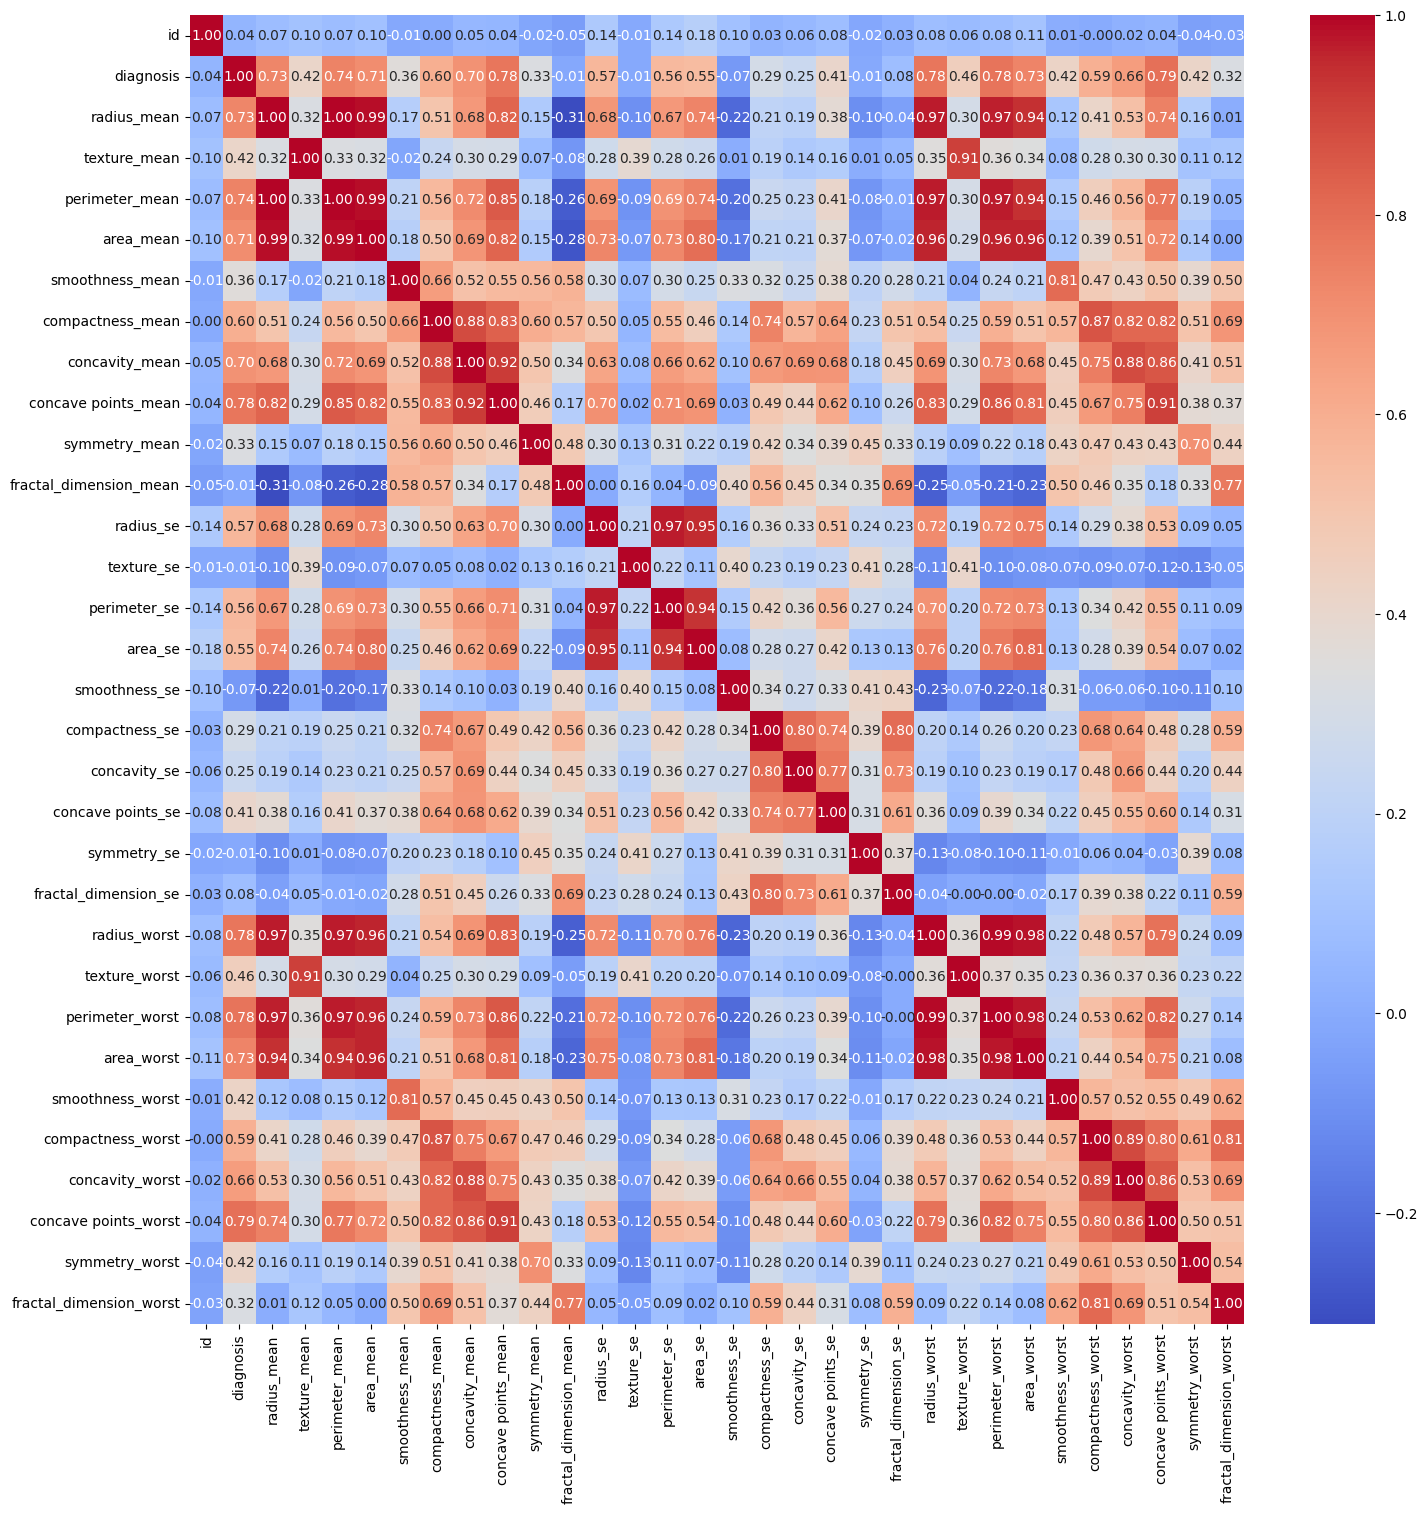

In [9]:
corr_matrix = data.corr()
plt.figure(figsize=(17, 17))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [10]:
corr_matrix = data.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
data.drop(to_drop, axis=1, inplace=True)

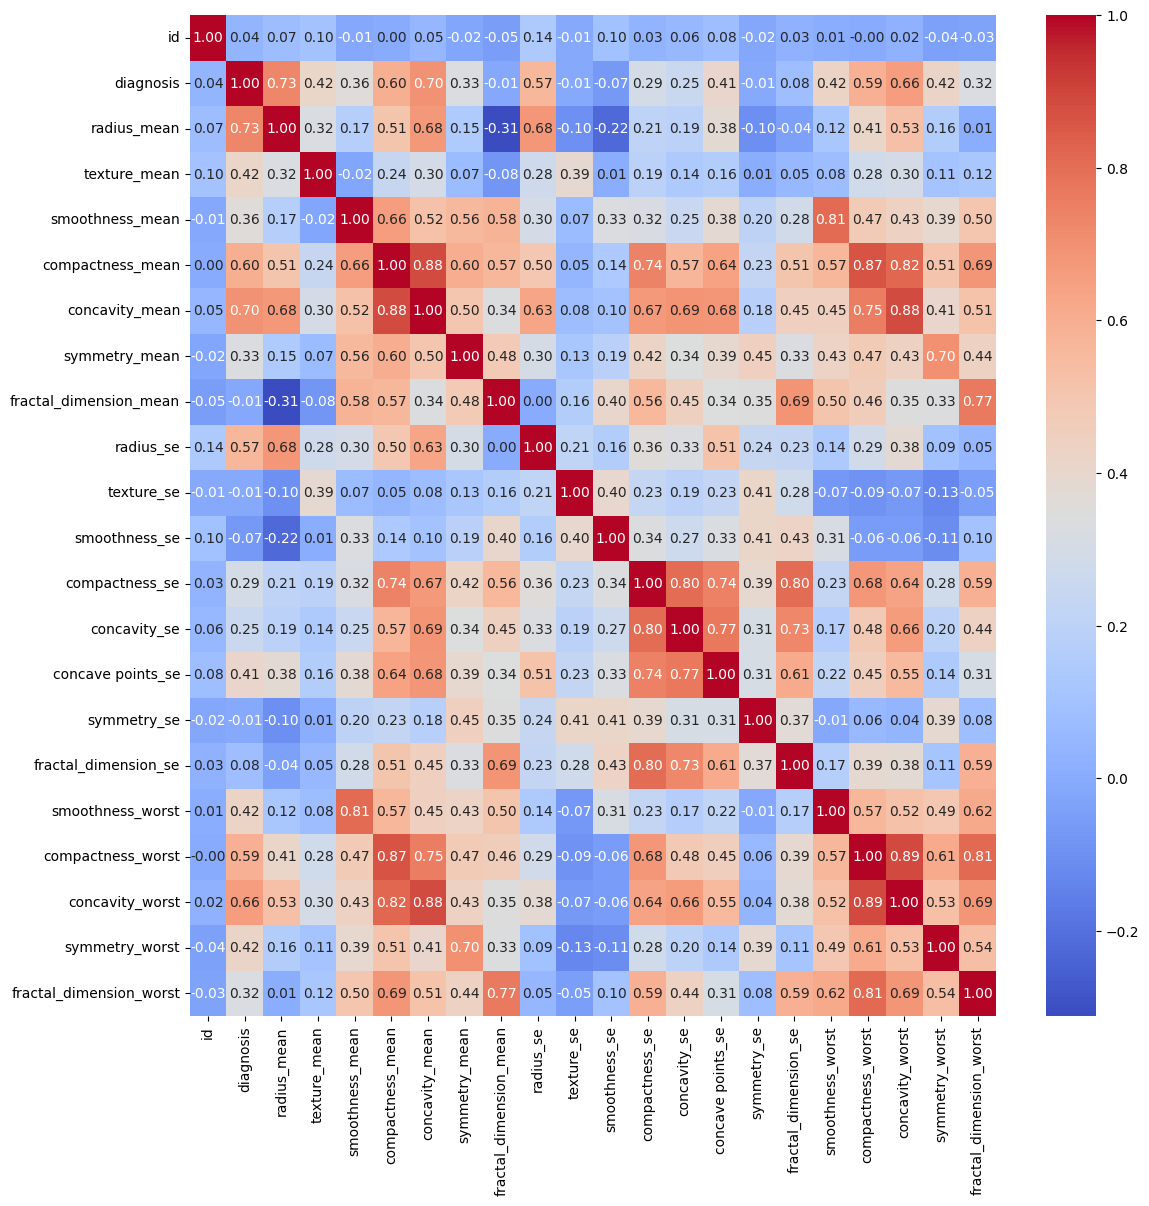

In [11]:

corr_matrix = data.corr()
plt.figure(figsize=(13, 13))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

<Axes: xlabel='smoothness_mean', ylabel='Count'>

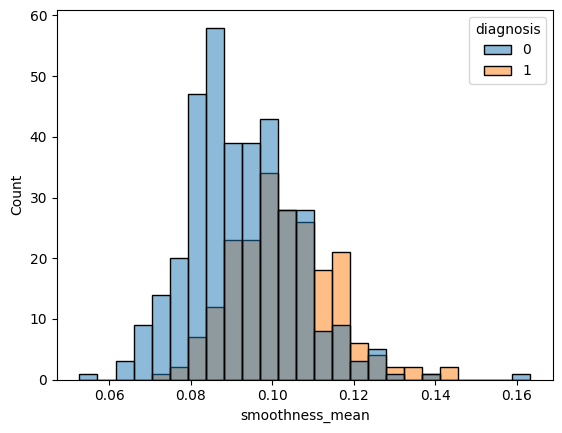

In [12]:
sns.histplot(x='smoothness_mean',hue='diagnosis',data=data)

In [13]:
data.columns.unique

<bound method Index.unique of Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'smoothness_mean',
       'compactness_mean', 'concavity_mean', 'symmetry_mean',
       'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'smoothness_worst', 'compactness_worst',
       'concavity_worst', 'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')>

In [14]:
data.describe()

,id,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,symmetry_mean,fractal_dimension_mean,radius_se,...,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,smoothness_worst,compactness_worst,concavity_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,0.372583,14.127292,19.289649,0.096360,0.104341,0.088799,0.181162,0.062798,0.405172,...,0.025478,0.031894,0.011796,0.020542,0.003795,0.132369,0.254265,0.272188,0.290076,0.083946
std,1.250206e+08,0.483918,3.524049,4.301036,0.014064,0.052813,0.079720,0.027414,0.007060,0.277313,...,0.017908,0.030186,0.006170,0.008266,0.002646,0.022832,0.157336,0.208624,0.061867,0.018061
min,8.670000e+03,0.000000,6.981000,9.710000,0.052630,0.019380,0.000000,0.106000,0.049960,0.111500,...,0.002252,0.000000,0.000000,0.007882,0.000895,0.071170,0.027290,0.000000,0.156500,0.055040
25%,8.692180e+05,0.000000,11.700000,16.170000,0.086370,0.064920,0.029560,0.161900,0.057700,0.232400,...,0.013080,0.015090,0.007638,0.015160,0.002248,0.116600,0.147200,0.114500,0.250400,0.071460
50%,9.060240e+05,0.000000,13.370000,18.840000,0.095870,0.092630,0.061540,0.179200,0.061540,0.324200,...,0.020450,0.025890,0.010930,0.018730,0.003187,0.131300,0.211900,0.226700,0.282200,0.080040
75%,8.813129e+06,1.000000,15.780000,21.800000,0.105300,0.130400,0.130700,0.195700,0.066120,0.478900,...,0.032450,0.042050,0.014710,0.023480,0.004558,0.146000,0.339100,0.382900,0.317900,0.092080
max,9.113205e+08,1.000000,28.110000,39.280000,0.163400,0.345400,0.426800,0.304000,0.097440,2.873000,...,0.135400,0.396000,0.052790,0.078950,0.029840,0.222600,1.058000,1.252000,0.663800,0.207500


In [15]:
data=data.drop(columns="id")

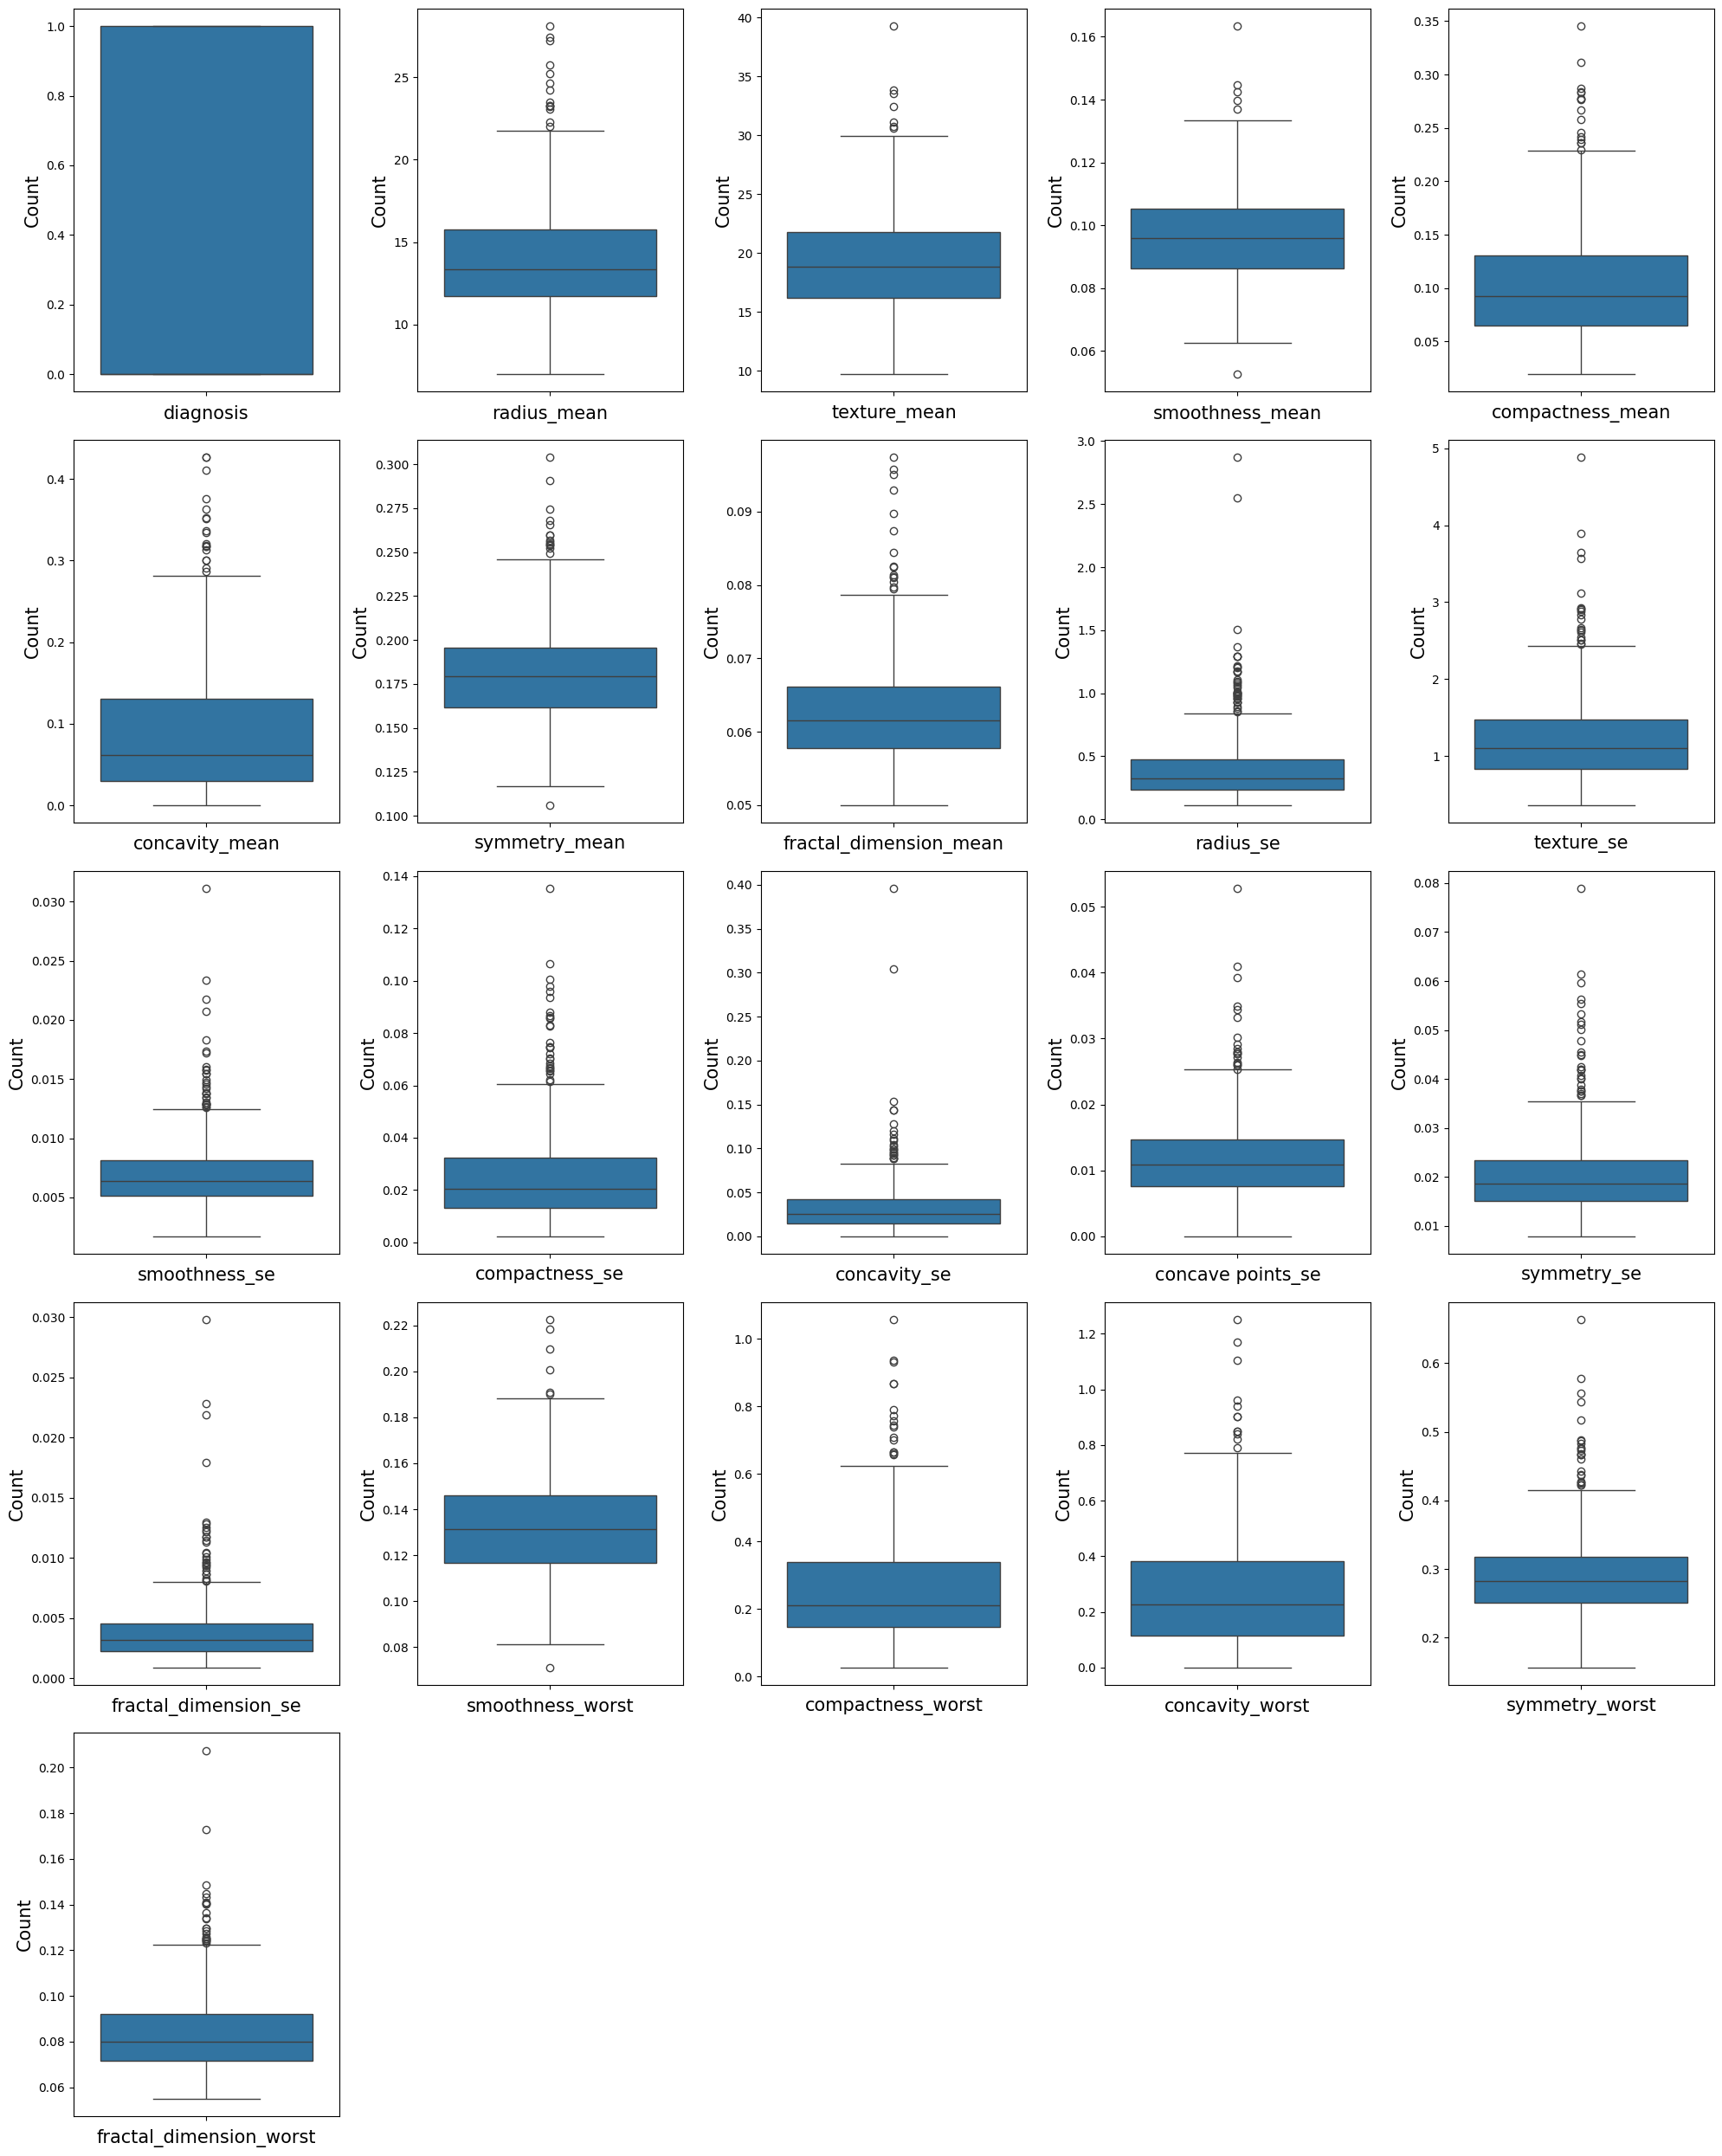

In [16]:
plt.figure(figsize=(20,25),facecolor='white')
plotnumber=1

for column in data:
    if plotnumber<=21:
        ax=plt.subplot(5,5,plotnumber)
        sns.boxplot(data[column])
        plt.xlabel(column,fontsize=15)
        plt.ylabel('Count',fontsize=15)
    plotnumber+=1
plt.tight_layout()

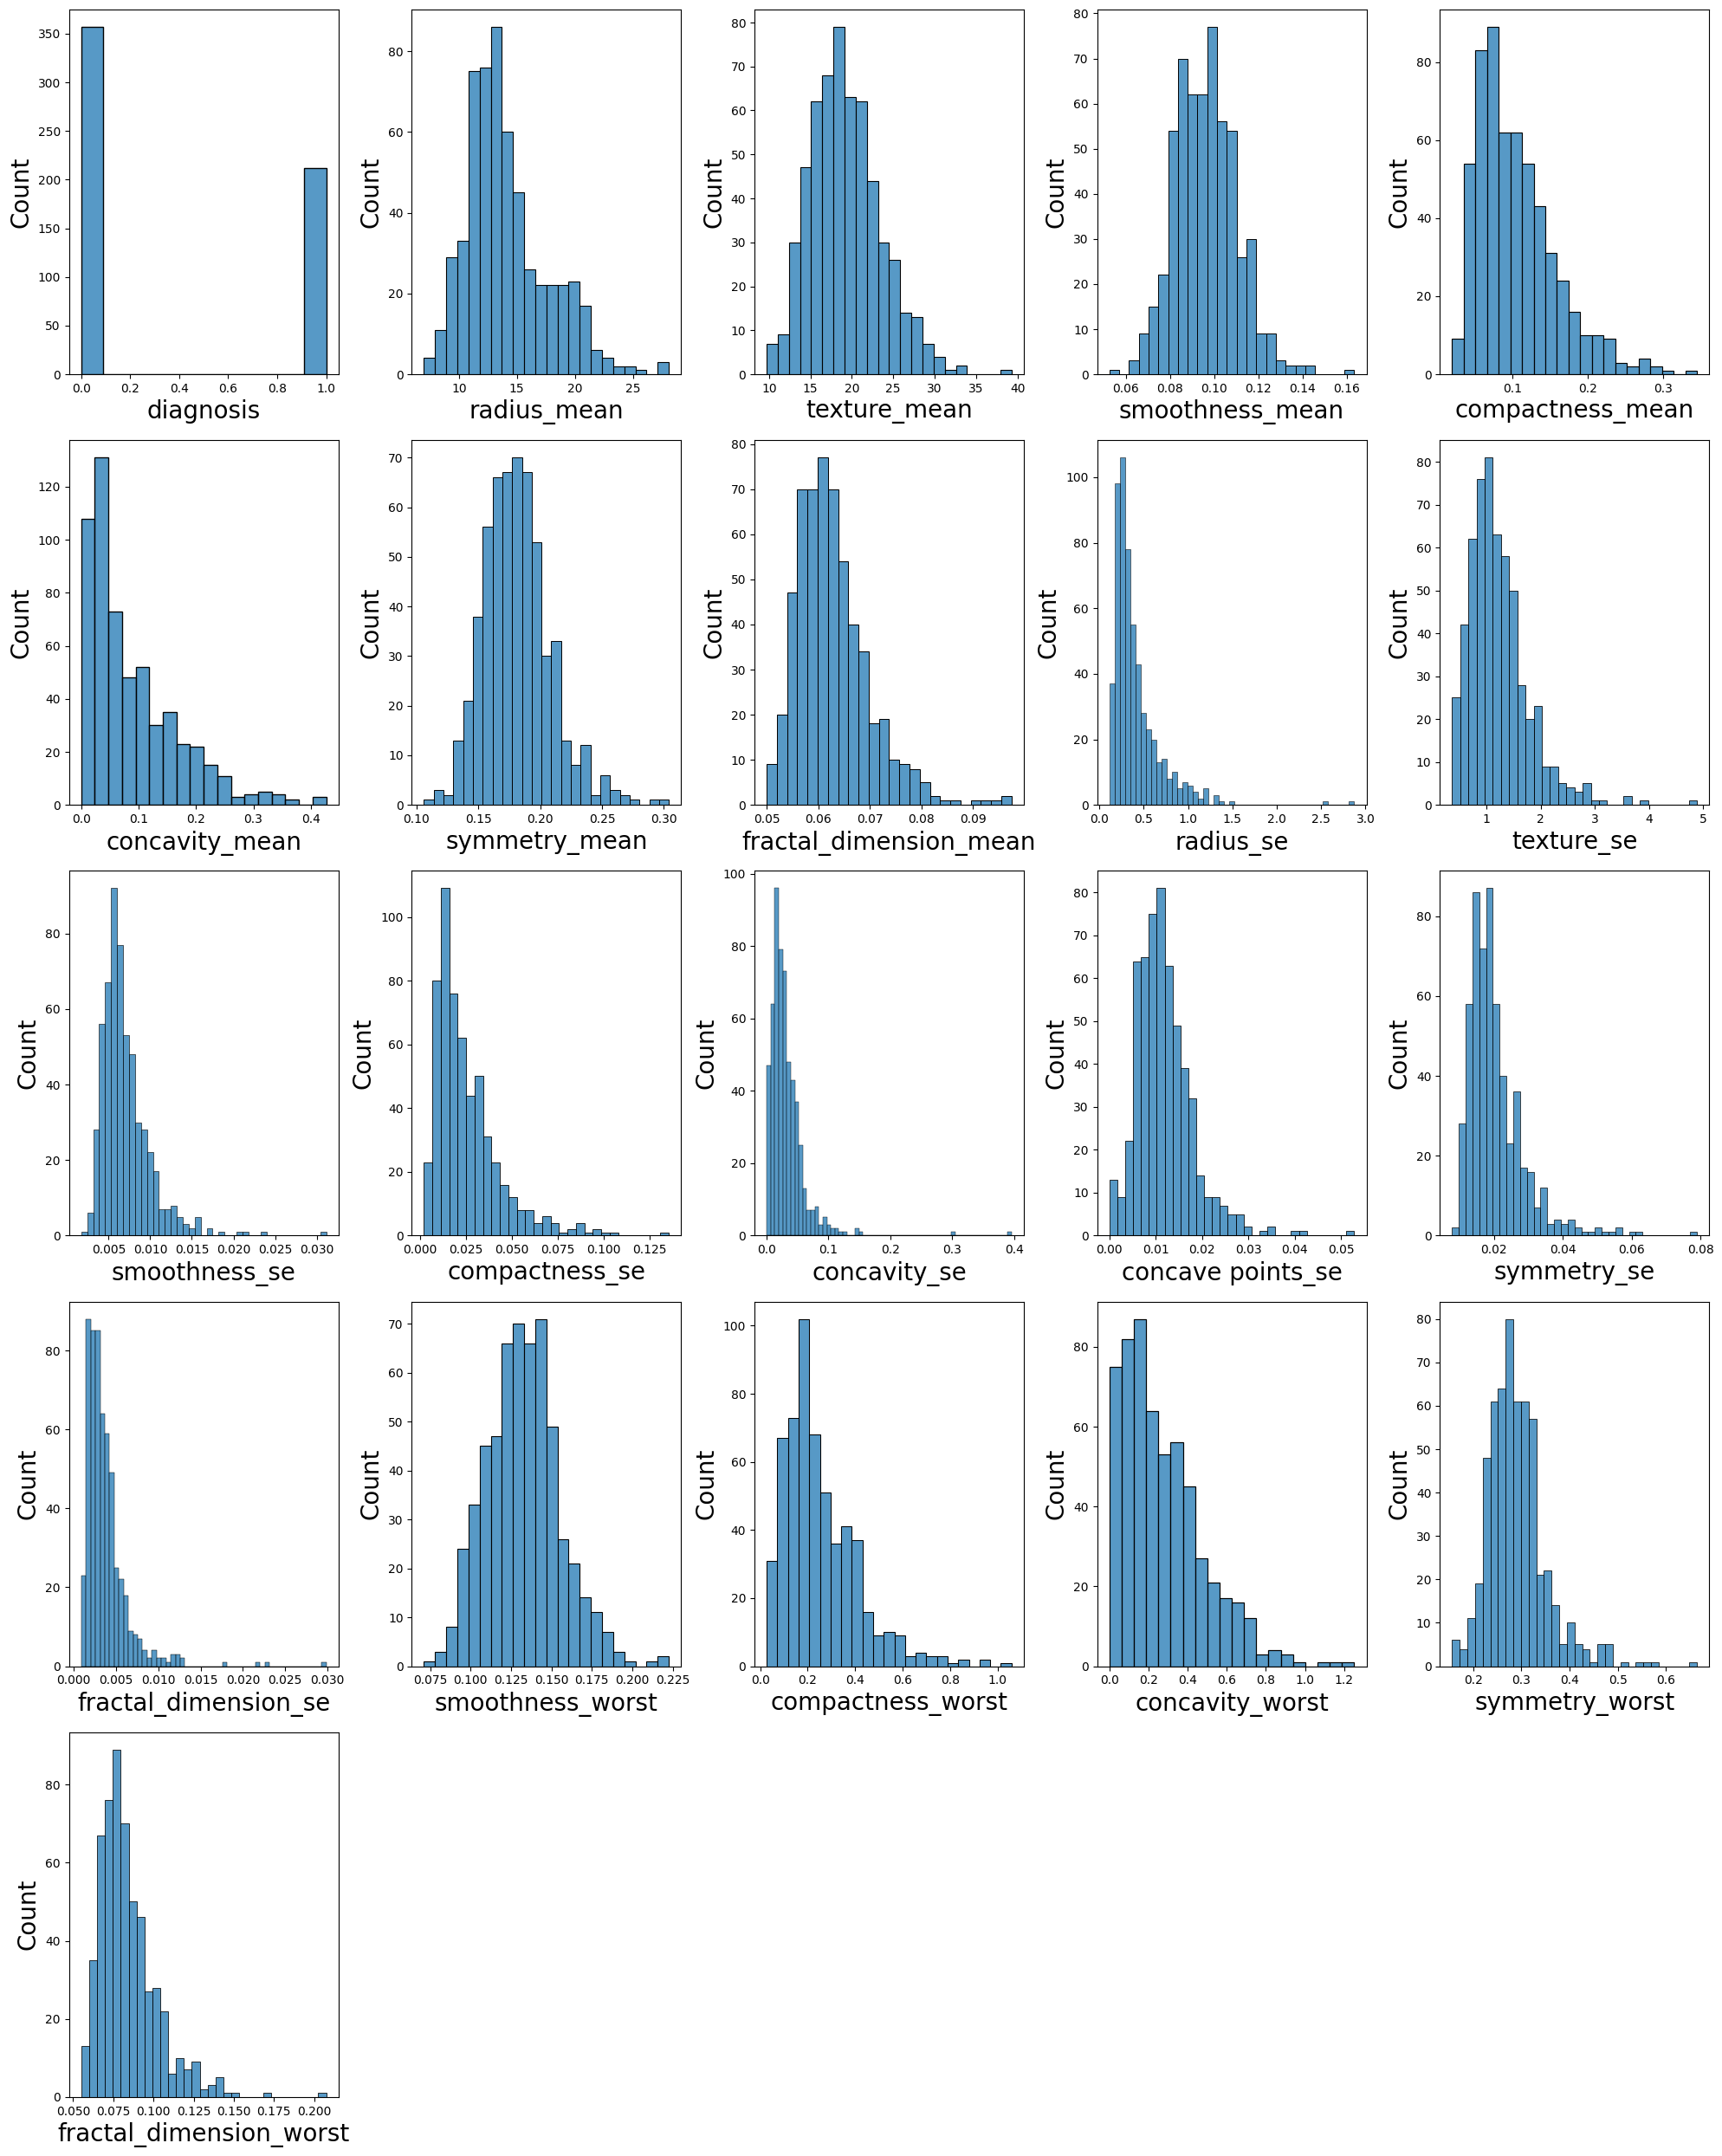

In [17]:
plt.figure(figsize=(20,25),facecolor='white')
plotnumber=1

for column in data:
    if plotnumber<=21:
        ax=plt.subplot(5,5,plotnumber)
        sns.histplot(data[column])
        plt.xlabel(column,fontsize=20)
        plt.ylabel('Count',fontsize=20)
    plotnumber+=1
plt.tight_layout()

In [18]:
from sklearn.preprocessing import MinMaxScaler
sc=MinMaxScaler()
dl=['diagnosis']
data1=sc.fit_transform(data.drop(dl,axis=1))

In [19]:
data1

array([[0.52103744, 0.0226581 , 0.59375282, ..., 0.56861022, 0.59846245,
        0.41886396],
       [0.64314449, 0.27257355, 0.28987993, ..., 0.19297125, 0.23358959,
        0.22287813],
       [0.60149557, 0.3902604 , 0.51430893, ..., 0.35974441, 0.40370589,
        0.21343303],
       ...,
       [0.45525108, 0.62123774, 0.28816467, ..., 0.27180511, 0.12872068,
        0.1519087 ],
       [0.64456434, 0.66351031, 0.58833619, ..., 0.74976038, 0.49714173,
        0.45231536],
       [0.03686876, 0.50152181, 0.        , ..., 0.        , 0.25744136,
        0.10068215]])

In [20]:
con_data=data[['diagnosis']]

In [21]:
data2=pd.DataFrame(data1,columns=['radius_mean', 'texture_mean', 'smoothness_mean',
       'compactness_mean', 'concavity_mean', 'symmetry_mean',
       'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'smoothness_worst', 'compactness_worst',
       'concavity_worst', 'symmetry_worst', 'fractal_dimension_worst'])

In [22]:
data2

,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,smoothness_worst,compactness_worst,concavity_worst,symmetry_worst,fractal_dimension_worst
0,0.521037,0.022658,0.593753,0.792037,0.703140,0.686364,0.605518,0.356147,0.120469,0.159296,0.351398,0.135682,0.300625,0.311645,0.183042,0.601136,0.619292,0.568610,0.598462,0.418864
1,0.643144,0.272574,0.289880,0.181768,0.203608,0.379798,0.141323,0.156437,0.082589,0.119387,0.081323,0.046970,0.253836,0.084539,0.091110,0.347553,0.154563,0.192971,0.233590,0.222878
2,0.601496,0.390260,0.514309,0.431017,0.462512,0.509596,0.211247,0.229622,0.094303,0.150831,0.283955,0.096768,0.389847,0.205690,0.127006,0.483590,0.385375,0.359744,0.403706,0.213433
3,0.210090,0.360839,0.811321,0.811361,0.565604,0.776263,1.000000,0.139091,0.175875,0.251453,0.543215,0.142955,0.353665,0.728148,0.287205,0.915472,0.814012,0.548642,1.000000,0.773711
4,0.629893,0.156578,0.430351,0.347893,0.463918,0.378283,0.186816,0.233822,0.093065,0.332359,0.167918,0.143636,0.357075,0.136179,0.145800,0.437364,0.172415,0.319489,0.157500,0.142595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,0.690000,0.428813,0.526948,0.296055,0.571462,0.336364,0.132056,0.385479,0.197976,0.291906,0.200213,0.131263,0.464861,0.045843,0.115536,0.461137,0.178527,0.328035,0.097575,0.105667
565,0.622320,0.626987,0.407782,0.257714,0.337395,0.349495,0.113100,0.236828,0.464728,0.137879,0.165064,0.099747,0.317863,0.156160,0.055387,0.300007,0.159997,0.256789,0.198502,0.074315
566,0.455251,0.621238,0.288165,0.254340,0.216753,0.267677,0.137321,0.124896,0.157974,0.142435,0.263301,0.119444,0.294942,0.074548,0.103547,0.282177,0.273705,0.271805,0.128721,0.151909
567,0.644564,0.663510,0.588336,0.790197,0.823336,0.675253,0.425442,0.222524,0.272896,0.163477,0.445579,0.179722,0.315211,0.216103,0.182766,0.619626,0.815758,0.749760,0.497142,0.452315


In [23]:
final_df=pd.concat([data2,con_data],axis=1)

In [24]:
final_df.head()

,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,...,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,smoothness_worst,compactness_worst,concavity_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,0.521037,0.022658,0.593753,0.792037,0.703140,0.686364,0.605518,0.356147,0.120469,0.159296,...,0.135682,0.300625,0.311645,0.183042,0.601136,0.619292,0.568610,0.598462,0.418864,1
1,0.643144,0.272574,0.289880,0.181768,0.203608,0.379798,0.141323,0.156437,0.082589,0.119387,...,0.046970,0.253836,0.084539,0.091110,0.347553,0.154563,0.192971,0.233590,0.222878,1
2,0.601496,0.390260,0.514309,0.431017,0.462512,0.509596,0.211247,0.229622,0.094303,0.150831,...,0.096768,0.389847,0.205690,0.127006,0.483590,0.385375,0.359744,0.403706,0.213433,1
3,0.210090,0.360839,0.811321,0.811361,0.565604,0.776263,1.000000,0.139091,0.175875,0.251453,...,0.142955,0.353665,0.728148,0.287205,0.915472,0.814012,0.548642,1.000000,0.773711,1
4,0.629893,0.156578,0.430351,0.347893,0.463918,0.378283,0.186816,0.233822,0.093065,0.332359,...,0.143636,0.357075,0.136179,0.145800,0.437364,0.172415,0.319489,0.157500,0.142595,1


In [25]:
final_df.describe()

,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,...,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,smoothness_worst,compactness_worst,concavity_worst,symmetry_worst,fractal_dimension_worst,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.338222,0.323965,0.394785,0.260601,0.208058,0.379605,0.270379,0.106345,0.189324,0.181119,...,0.080540,0.223454,0.178143,0.100193,0.404138,0.220212,0.217403,0.263307,0.189596,0.372583
std,0.166787,0.145453,0.126967,0.161992,0.186785,0.138456,0.148702,0.100421,0.121917,0.102067,...,0.076227,0.116884,0.116316,0.091417,0.150779,0.152649,0.166633,0.121954,0.118466,0.483918
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.223342,0.218465,0.304595,0.139685,0.069260,0.282323,0.163016,0.043781,0.104690,0.117483,...,0.038106,0.144686,0.102409,0.046750,0.300007,0.116337,0.091454,0.185098,0.107700,0.000000
50%,0.302381,0.308759,0.390358,0.224679,0.144189,0.369697,0.243892,0.077023,0.165267,0.158650,...,0.065379,0.207047,0.152643,0.079191,0.397081,0.179110,0.181070,0.247782,0.163977,0.000000
75%,0.416442,0.408860,0.475490,0.340531,0.306232,0.453030,0.340354,0.133044,0.246155,0.218683,...,0.106187,0.278651,0.219480,0.126556,0.494156,0.302520,0.305831,0.318155,0.242949,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [26]:
X=final_df.iloc[:,:-1]
y=final_df.diagnosis

In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)

In [33]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()
clf.fit(X_train_smote, y_train_smote)

LogisticRegression()

In [34]:
y_pred=clf.predict(X_test)

In [35]:
y_pred

array([0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0], dtype=int64)

In [36]:
y_pred_prob=clf.predict_proba(X_test)
y_pred_prob

array([[6.44162539e-01, 3.55837461e-01],
       [1.43216738e-01, 8.56783262e-01],
       [1.59275712e-01, 8.40724288e-01],
       [8.40282571e-01, 1.59717429e-01],
       [9.28946621e-01, 7.10533789e-02],
       [2.93688696e-04, 9.99706311e-01],
       [9.08352640e-03, 9.90916474e-01],
       [4.31291132e-01, 5.68708868e-01],
       [3.76272507e-01, 6.23727493e-01],
       [9.02006581e-01, 9.79934190e-02],
       [7.26646345e-01, 2.73353655e-01],
       [3.92595048e-01, 6.07404952e-01],
       [8.28051211e-01, 1.71948789e-01],
       [2.50220322e-01, 7.49779678e-01],
       [8.95906353e-01, 1.04093647e-01],
       [1.42161722e-01, 8.57838278e-01],
       [8.73261564e-01, 1.26738436e-01],
       [9.63685838e-01, 3.63141616e-02],
       [9.91174246e-01, 8.82575395e-03],
       [2.84509609e-02, 9.71549039e-01],
       [6.69986180e-01, 3.30013820e-01],
       [7.85797796e-01, 2.14202204e-01],
       [2.84494277e-03, 9.97155057e-01],
       [9.72056914e-01, 2.79430863e-02],
       [8.974681

In [29]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()

In [30]:
y_train.value_counts()

diagnosis
0    268
1    158
Name: count, dtype: int64

In [31]:
X_train_smote, y_train_smote = smote.fit_resample(X_train.astype('float'),y_train)

In [32]:
y=np.array(y_train_smote)

In [37]:
from collections import Counter
print("Actual Classes",Counter(y_train))
print("SMOTE Classes",Counter(y_train_smote))

Actual Classes Counter({0: 268, 1: 158})
SMOTE Classes Counter({0: 268, 1: 268})


In [38]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()
clf.fit(X_train_smote, y_train_smote)

LogisticRegression()

In [39]:
y_pred = clf.predict(X_test)

In [40]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,classification_report,f1_score

In [41]:
print("The accuracy score is : ", accuracy_score(y_test,y_pred))

The accuracy score is :  0.965034965034965


In [42]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97        89
           1       0.95      0.96      0.95        54

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.97      0.97      0.97       143



In [43]:
from sklearn.neighbors import KNeighborsClassifier


In [44]:
knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train_smote, y_train_smote)

KNeighborsClassifier()

In [45]:
y_pred = knn2.predict(X_test)

In [46]:
print("The accuracy score is : ", accuracy_score(y_test,y_pred))

The accuracy score is :  0.958041958041958


In [47]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97        89
           1       0.93      0.96      0.95        54

    accuracy                           0.96       143
   macro avg       0.95      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143



In [ ]:
## Scaling the data as the magnitude of variables are varying lot
from sklearn.preprocessing import StandardScaler
sc=StandardScaler() ## object creation
sclaed_x=sc.fit_transform(X_train_smote) ## transforming the data
X = pd.DataFrame(sclaed_x,columns=X_train_smote
                 ) ##converting the arrays
## to dataframe

ValueError: Index data must be 1-dimensional

: 

In [49]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

ValueError: Found input variables with inconsistent numbers of samples: [569, 536]